# Netflix Data Analysis

Exploratory Data Analysis of Netflix movies and TV shows using Python, Pandas, Matplotlib, and Seaborn.

The goal is to understand content type distribution, country contributions, genre trends, ratings, monthly additions, and movie duration patterns.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
df = pd.read_csv('netflix_titles.csv')


## 1. Load Libraries and Dataset


In [2]:
df.columns.tolist()


<bound method IndexOpsMixin.tolist of Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')>

## 2. Initial Data Inspection


In [3]:
df.head()


<bound method NDFrame.head of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabal

In [4]:
df.shape


(8807, 12)

In [5]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df["country"].fillna("Unknown", inplace=True)
df["rating"].fillna("Not Rated", inplace=True)
df["duration"].fillna("Unknown", inplace=True)


C:\Users\thisi\AppData\Local\Temp\ipykernel_30008\395795384.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["country"].fillna("Unknown", inplace=True)
C:\Users\thisi\AppData\Local\Temp\ipykernel_30008\395795384.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

## 3. Data Cleaning and Feature Engineering


In [7]:
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month


In [8]:
print(df[["country", "rating", "year_added"]].isnull().sum())


country        0
rating         0
year_added    10
dtype: int64


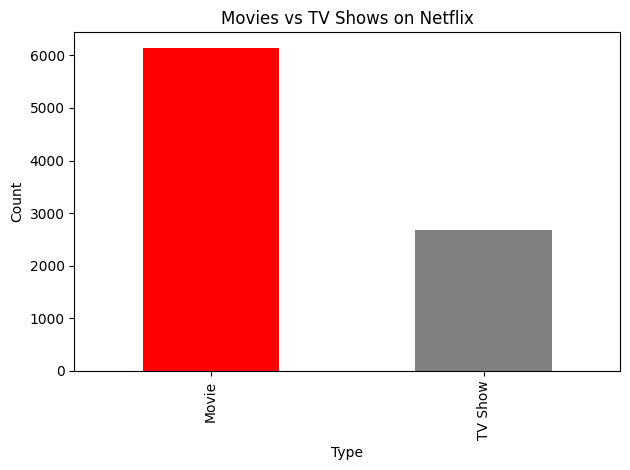

In [9]:
df["type"].value_counts().plot(kind="bar", color=["red", "gray"])
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 4. Movies vs TV Shows


C:\Users\thisi\AppData\Local\Temp\ipykernel_30008\1409663086.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="Reds_r")


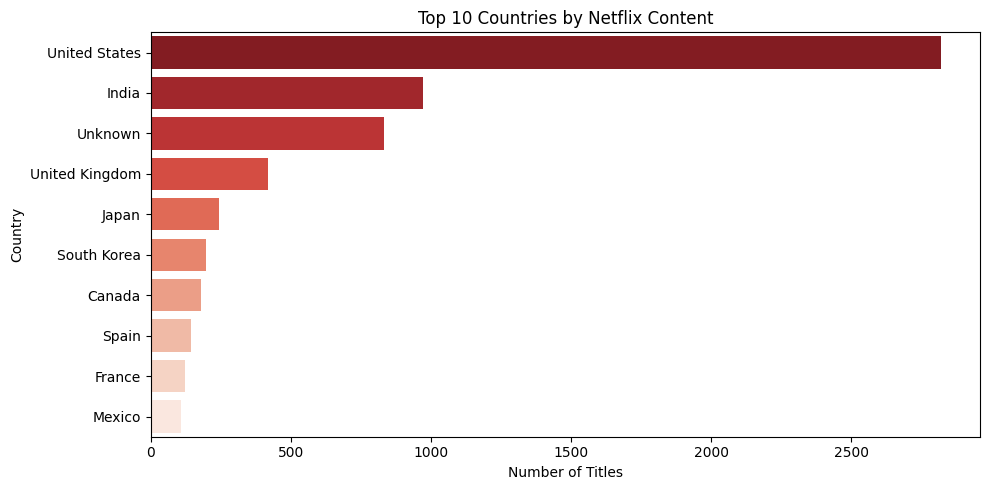

In [10]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="Reds_r")
plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


## 5. Top Countries by Content


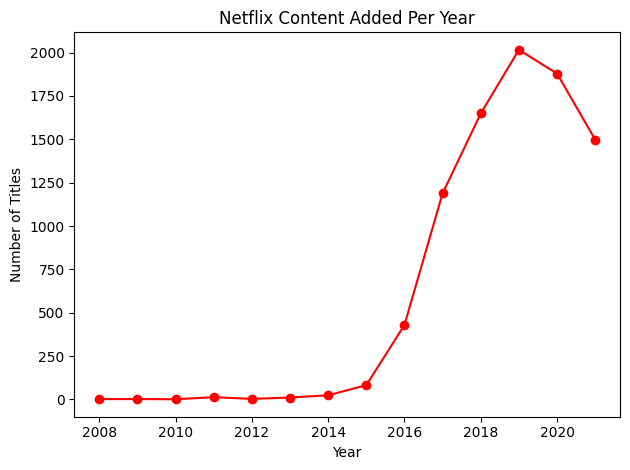

In [11]:

df["year_added"].value_counts().sort_index().plot(kind="line", color="red", marker="o")
plt.title("Netflix Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()


## 6. Content Added Over Time


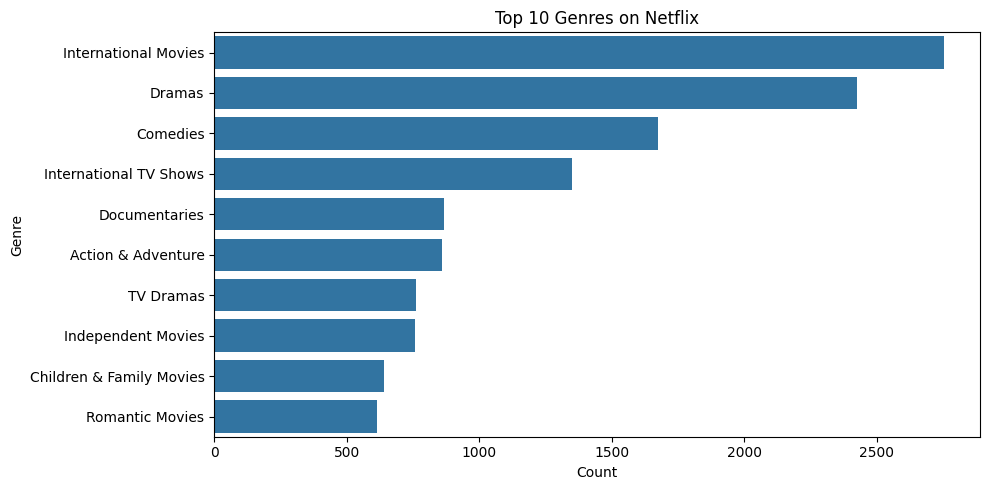

In [12]:
genres = df["listed_in"].str.split(", ").explode()
top_genres = pd.Series(Counter(genres)).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


## 7. Top Genres


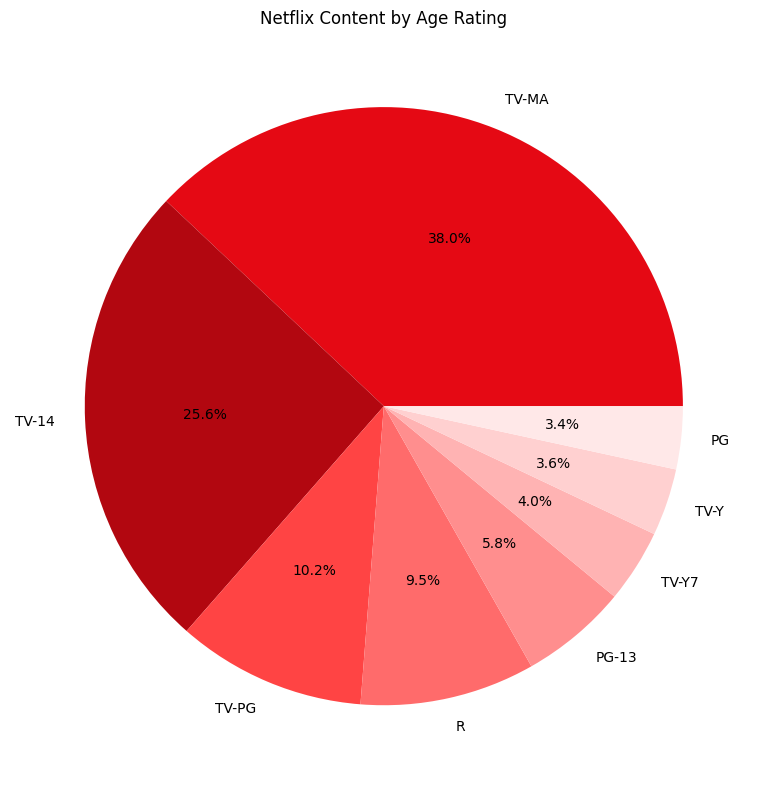

In [13]:
plt.figure(figsize=(8,8))
df["rating"].value_counts().head(8).plot(
    kind="pie", 
    autopct="%1.1f%%", 
    colors=["#E50914","#B20710","#FF4444","#FF6B6B","#FF8E8E","#FFB3B3","#FFD0D0","#FFE8E8"]
)
plt.title("Netflix Content by Age Rating")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 8. Age Rating Distribution


C:\Users\thisi\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\thisi\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\thisi\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\thisi\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:854: F

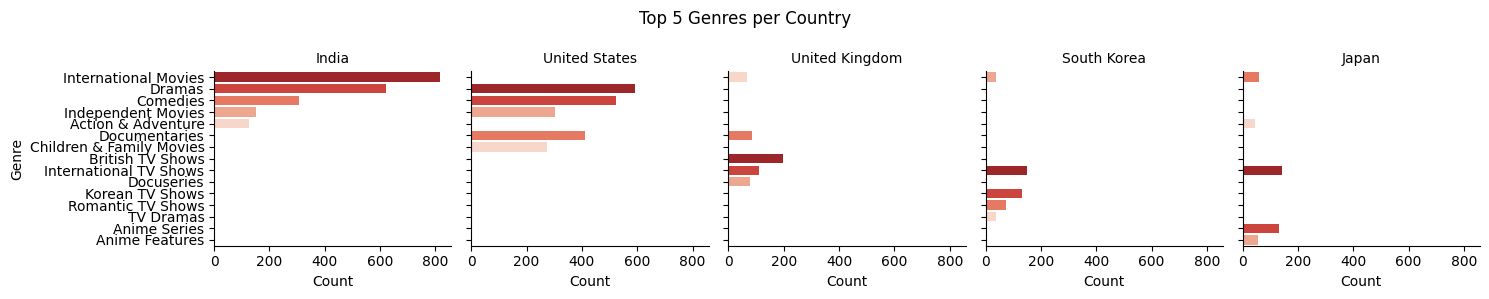

In [ ]:
df_single = df[~df["country"].str.contains(",", na=True)]

df_exploded2 = df_single.assign(genre=df_single["listed_in"].str.split(", ")).explode("genre")

# Pick specific countries
countries = ["India", "United States", "United Kingdom", "Japan", "South Korea"]
df_filtered2 = df_exploded2[df_exploded2["country"].isin(countries)]

# Top 5 genres per country
top_genres2 = df_filtered2.groupby(["country", "genre"]).size().reset_index(name="count")
top_genres2 = top_genres2.sort_values("count", ascending=False).groupby("country").head(5)

g = sns.FacetGrid(top_genres2, col="country")
g.map_dataframe(sns.barplot, x="count", y="genre", palette="Reds_r")
g.set_titles("{col_name}")
g.set_axis_labels("Count", "Genre")
plt.suptitle("Top 5 Genres per Country")
plt.tight_layout()
plt.show()


## 9. Top Genres by Selected Countries


C:\Users\thisi\AppData\Local\Temp\ipykernel_30008\2836715914.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_counts.index, y=month_counts.values, palette="Reds_r")


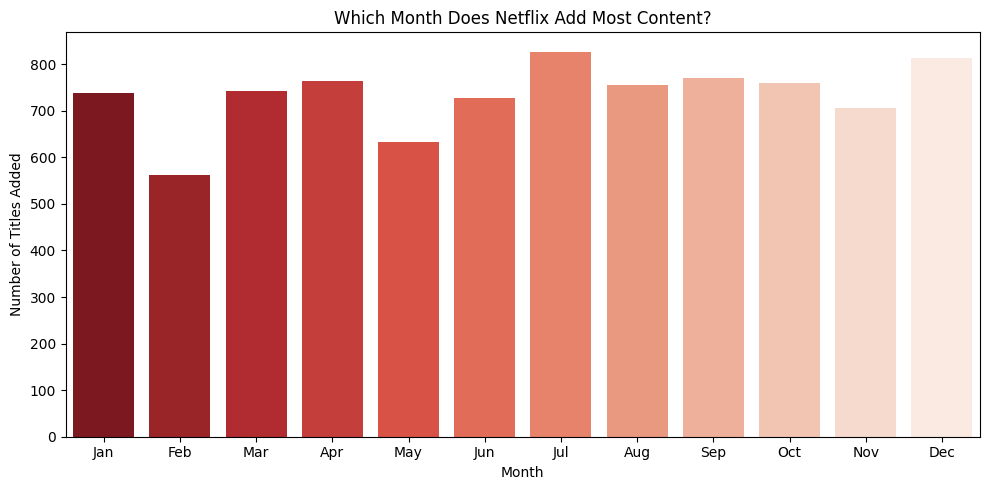

In [15]:
import calendar

month_counts = df["month_added"].dropna().astype(int).value_counts().sort_index()
month_counts.index = [calendar.month_abbr[i] for i in month_counts.index]

plt.figure(figsize=(10,5))
sns.barplot(x=month_counts.index, y=month_counts.values, palette="Reds_r")
plt.title("Which Month Does Netflix Add Most Content?")
plt.xlabel("Month")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.show()


## 10. Monthly Content Addition Pattern


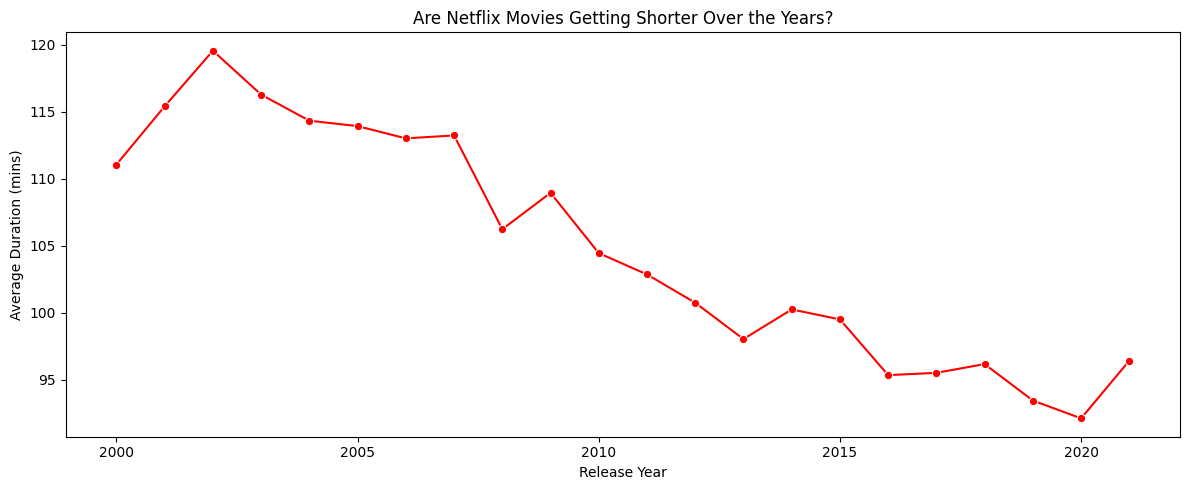

In [16]:
# Filter only movies and extract duration as number
movies_df = df[df["type"] == "Movie"].copy()
movies_df["duration_mins"] = movies_df["duration"].str.extract(r"(\d+)").astype(float)

# Average duration per year
avg_duration = movies_df.groupby("release_year")["duration_mins"].mean().reset_index()

# Filter only recent years for cleaner chart
avg_duration = avg_duration[avg_duration["release_year"] >= 2000]

plt.figure(figsize=(12,5))
sns.lineplot(data=avg_duration, x="release_year", y="duration_mins", color="red", marker="o")
plt.title("Are Netflix Movies Getting Shorter Over the Years?")
plt.xlabel("Release Year")
plt.ylabel("Average Duration (mins)")
plt.tight_layout()
plt.show()


## 11. Movie Duration Trend
